# ACTIVIDAD 2: REDES NEURONALES CONVOLUCIONALES

---

En esta actividad, vamos a trabajar con Convolutional Neural Networks para resolver un problema de clasificación de imágenes. En particular, vamos a clasificar imágenes de personajes de la conocida serie de los Simpsons.

Como las CNN profundas son un tipo de modelo bastante avanzado y computacionalmente costoso, se recomienda hacer la práctica en Google Colaboratory con soporte para GPUs. En [este enlace](https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) se explica cómo activar un entorno con GPUs. *Nota: para leer las imágenes y estandarizarlas al mismo tamaño se usa la librería opencv. Esta ĺibrería está ya instalada en el entorno de Colab, pero si trabajáis de manera local tendréis que instalarla.*

<center><img src="https://i.imgur.com/i8zIGqX.jpg" style="text-align: center" height="300px"></center>

El dataset a utilizar consiste en imágenes de personajes de los Simpsons extraídas directamente de capítulos de la serie. Este dataset ha sido recopilado por [Alexandre Attia](http://www.alexattia.fr/) y es más complejo que el dataset de Fashion MNIST que hemos utilizado hasta ahora. Aparte de tener más clases (vamos a utilizar los 18 personajes con más imágenes), los personajes pueden aparecer en distintas poses, en distintas posiciones de la imagen o con otros personajes en pantalla (si bien el personaje a clasificar siempre aparece en la posición predominante).

El dataset de training puede ser descargado desde aquí:

[Training data](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219337&authkey=AMzI92bJPx8Sd60) (~500MB)

Por otro lado, el dataset de test puede ser descargado de aquí:

[Test data](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219341&authkey=ANnjK3Uq1FhuAe8) (~10MB)

Antes de empezar la práctica, se recomienda descargar las imágenes y echarlas un vistazo.


In [1]:
import tensorflow as tf

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print("✅ Metal GPU listo")
else:
    print("No GPU")

TF version: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Metal GPU listo


## Carga de los datos

In [3]:
import cv2
import os
import numpy as np
import pandas as pd
import keras
from tensorflow import keras
import matplotlib.pyplot as plt
import glob
# import tensorflow as tf
import random


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%pip install scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 16.5 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 13.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-image] [scikit-image]
Note: you may need to restart the kernel to use updated packages.


In [47]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, Input
from tensorflow.keras.applications import EfficientNetB4, MobileNetV2, NASNetMobile, Xception, ResNet50V2
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad
from keras.optimizers.schedules import ExponentialDecay, CosineDecayRestarts
from keras.losses import SparseCategoricalCrossentropy, CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy
from tensorflow.keras import layers
from tensorflow.keras import Model
import keras_preprocessing
from keras_preprocessing import image
from keras_preprocessing.image import ImageDataGenerator
from keras.models import load_model
from keras.regularizers import l2
from skimage.color import rgb2gray
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.utils import class_weight
plt.rcParams["figure.figsize"] = (20,6)

In [ ]:
%pip install kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kagglehub]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import kagglehub

/Users/justindavila/desarrollo/ML-codes/venv-metal/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
path = kagglehub.dataset_download("alfaro96/los-simpson")

print("Dataset descargado en:", path)

100%|██████████| 488M/488M [00:32<00:00, 15.7MB/s] 

Extracting files...


Dataset descargado en: /Users/justindavila/.cache/kagglehub/datasets/alfaro96/los-simpson/versions/5


In [6]:
# import os

# Ver qué contiene el dataset
# path quemado para no volver a descargar el dataset
path = "/Users/justindavila/.cache/kagglehub/datasets/alfaro96/los-simpson/versions/5"
for folder in os.listdir(path):
    print(folder)

test
train


In [ ]:
# IMPORTANTE: esta celda descargaba el dataset de onedrive, por ahora no esta habilitado el servidor con el dataset
#  # Primero, bajamos los datos de entrenamiento
# keras.utils.get_file(fname="simpsons_train.tar.gz",
#                      origin="https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219337&authkey=AMzI92bJPx8Sd60")

# # Descomprimimos el archivo
# !tar -xzf /root/.keras/datasets/simpsons_train.tar.gz -C /root/.keras/datasets


# # Hacemos lo mismo con los datos de test
# keras.utils.get_file(fname="simpsons_test.tar.gz",
#                      origin="https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219341&authkey=ANnjK3Uq1FhuAe8")
# !tar -xzf /root/.keras/datasets/simpsons_test.tar.gz -C /root/.keras/datasets

Exception: URL fetch failure on https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219337&authkey=AMzI92bJPx8Sd60: 500 -- Internal Server Error

In [ ]:
# Descomprimimos el archivo en tmp para visualizar
# !tar -xzf /root/.keras/datasets/simpsons_train.tar.gz -C /tmp/simpsons

In [7]:
# Esta variable contiene un mapeo de número de clase a personaje.
# Utilizamos sólo los 18 personajes del dataset que tienen más imágenes.
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel',
    7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lisa_simpson',
    11: 'marge_simpson', 12: 'milhouse_van_houten', 13: 'moe_szyslak',
    14: 'ned_flanders', 15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}
list_caracters = list(MAP_CHARACTERS.values())
# Vamos a standarizar todas las imágenes a tamaño 64x64
IMG_SIZE = 60


In [8]:
def load_train_set(dirname, map_characters, verbose=True):
    """Esta función carga los datos de training en imágenes.

    Como las imágenes tienen tamaños distintas, utilizamos la librería opencv
    para hacer un resize y adaptarlas todas a tamaño IMG_SIZE x IMG_SIZE.

    Args:
        dirname: directorio completo del que leer los datos
        map_characters: variable de mapeo entre labels y personajes
        verbose: si es True, muestra información de las imágenes cargadas

    Returns:
        X, y: X es un array con todas las imágenes cargadas con tamaño
                IMG_SIZE x IMG_SIZE
              y es un array con las labels de correspondientes a cada imagen
    """
    X_train = []
    y_train = []
    for label, character in map_characters.items():
        files = os.listdir(os.path.join(dirname, character))
        images = [file for file in files if file.endswith("jpg")]
        if verbose:
          print("Leyendo {} imágenes encontradas de {}".format(len(images), character))
        for image_name in images:
            image = cv2.imread(os.path.join(dirname, character, image_name))
            X_train.append(cv2.resize(image,(IMG_SIZE, IMG_SIZE)))
            y_train.append(label)
    return np.array(X_train), np.array(y_train)

In [9]:
def load_test_set(dirname, map_characters, verbose=True):
    """Esta función funciona de manera equivalente a la función load_train_set
    pero cargando los datos de test."""
    X_test = []
    y_test = []
    reverse_dict = {v: k for k, v in map_characters.items()}
    for filename in glob.glob(dirname):
        print("filename: ", filename)
        char_name = "_".join(filename.split('/')[-1].split('_')[:-1])
        if char_name in reverse_dict:
            image = cv2.imread(filename)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            X_test.append(image)
            y_test.append(reverse_dict[char_name])
    if verbose:
        print("Leídas {} imágenes de test".format(len(X_test)))
    return np.array(X_test), np.array(y_test)


In [10]:
# Cargamos los datos. Si no estás trabajando en colab, cambia los paths por
# los de los ficheros donde hayas descargado los datos.
# Rutas de train y test
TRAIN_DIR = os.path.join(path, "train")
TEST_DIR = os.path.join(path, "test")

# Verificar cuántas clases hay
clases = os.listdir(TRAIN_DIR)
# print(f"Clases encontradas: {len(clases)}")
# print(clases[:10])

# DATASET_TRAIN_PATH_COLAB = "/root/.keras/datasets/simpsons"
# DATASET_TEST_PATH_COLAB = "/root/.keras/datasets/simpsons_testset"

X, y = load_train_set(TRAIN_DIR, MAP_CHARACTERS)
X_t, y_t = load_test_set(TEST_DIR, MAP_CHARACTERS)

Leyendo 730 imágenes encontradas de abraham_grampa_simpson
Leyendo 498 imágenes encontradas de apu_nahasapeemapetilon
Leyendo 1073 imágenes encontradas de bart_simpson
Leyendo 954 imágenes encontradas de charles_montgomery_burns
Leyendo 788 imágenes encontradas de chief_wiggum
Leyendo 375 imágenes encontradas de comic_book_guy
Leyendo 365 imágenes encontradas de edna_krabappel
Leyendo 1796 imágenes encontradas de homer_simpson
Leyendo 398 imágenes encontradas de kent_brockman
Leyendo 964 imágenes encontradas de krusty_the_clown
Leyendo 1083 imágenes encontradas de lisa_simpson
Leyendo 1032 imágenes encontradas de marge_simpson
Leyendo 863 imágenes encontradas de milhouse_van_houten
Leyendo 1161 imágenes encontradas de moe_szyslak
Leyendo 1163 imágenes encontradas de ned_flanders
Leyendo 286 imágenes encontradas de nelson_muntz
Leyendo 955 imágenes encontradas de principal_skinner
Leyendo 701 imágenes encontradas de sideshow_bob
filename:  /Users/justindavila/.cache/kagglehub/datasets/a

In [79]:
TEST_DIR

'/Users/justindavila/.cache/kagglehub/datasets/alfaro96/los-simpson/versions/5/test'

In [11]:
# Vamos a barajar aleatoriamente los datos. Esto es importante ya que si no
# lo hacemos y, por ejemplo, cogemos el 20% de los datos finales como validation
# set, estaremos utilizando solo un pequeño número de personajes, ya que
# las imágenes se leen secuencialmente personaje a personaje.
perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]

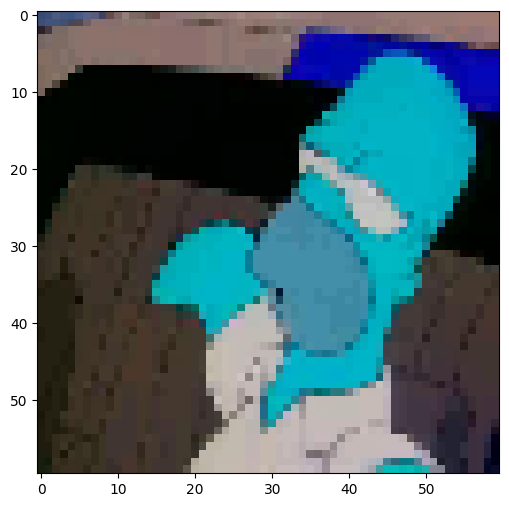

In [81]:
plt.imshow(X[2])

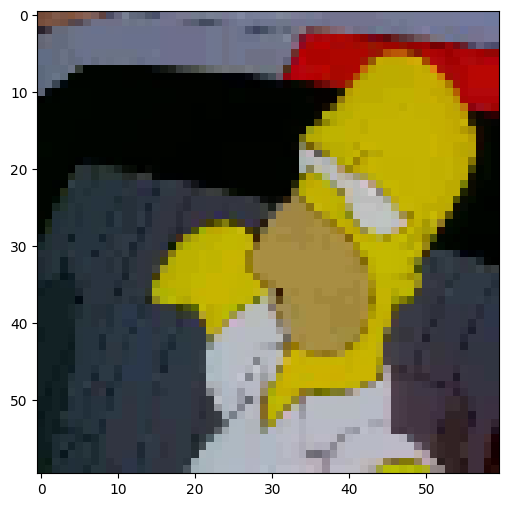

In [82]:
plt.imshow(np.flip(X[2], axis=-1) )

## Ejercicio

Utilizando Convolutional Neural Networks con Keras, entrenar un clasificador que sea capaz de reconocer personajes en imágenes de los Simpsons con una accuracy en el dataset de test de, al menos, **85%**. Redactar un informe analizando varias de las alternativas probadas y los resultados obtenidos.

A continuación se detallan una serie de aspectos para ser analizados en vuestro informe:

*   Análisis de los datos a utilizar.
*   Análisis de resultados, obtención de métricas de *precision* y *recall* por clase y análisis de qué clases obtienen mejores o peores resultados.
*   Análisis visual de los errores de la red. ¿Qué tipo de imágenes o qué personajes dan más problemas a nuestro modelo?
*   Comparación de modelos CNNs con un modelo de Fully Connected para este problema.
*   Utilización de distintas arquitecturas CNNs, comentando aspectos como su profundidad, hiperparámetros utilizados, optimizador, uso de técnicas de regularización, *batch normalization*, etc.
*   Utilización de *data augmentation*. Esto puede conseguirse con la clase [ImageDataGenerator](https://keras.io/preprocessing/image/#imagedatagenerator-class) de Keras.

Notas:
* Recuerda partir los datos en training/validation para tener una buena estimación de los valores que nuestro modelo tendrá en los datos de test, así como comprobar que no estamos cayendo en overfitting. Una posible partición puede ser 80 / 20.
* No es necesario mostrar en el notebook las trazas de entrenamiento de todos los modelos entrenados, si bien una buena idea seria guardar gráficas de esos entrenamientos para el análisis. Sin embargo, **se debe mostrar el entrenamiento completo del mejor modelo obtenido y la evaluación de los datos de test con este modelo**.
* Las imágenes **no están normalizadas**. Hay que normalizarlas como hemos hecho en trabajos anteriores.
* El test set del problema tiene imágenes un poco más "fáciles", por lo que es posible encontrarse con métricas en el test set bastante mejores que en el training set.

In [12]:
#Función para graficar resultados del performance del modelo
def PlotPerformance(acc, val_acc, loss, val_loss, name_exp):
    accuracy = acc
    val_accuracy = val_acc
    loss_model = loss
    val_loss_model = val_loss
    Accname = f'{name_exp} Accuracy'
    Lossname = f'{name_exp} Loss'

    epochs = range(len (accuracy))

    #------------------------------------------------
    # Accuracy
    #------------------------------------------------

    plt.plot(epochs, accuracy,'b',label='Training accuracy')
    plt.plot(epochs, val_accuracy,'r',label='Validation accuracy')
    plt.title(Accname)
    plt.legend()
    plt.figure()

    #------------------------------------------------
    # Loss
    #------------------------------------------------

    plt.plot(epochs, loss_model, 'b', label='Training Loss')
    plt.plot(epochs, val_loss_model, 'r', label='Validation Loss')
    plt.title(Lossname)
    plt.legend()
    plt.show()

In [13]:
def display_images(set_img, y_label, num_rows, num_cols):

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(9, 9))
    axes = axes.ravel()

    for i in range(len(set_img)):
        plt.tight_layout()
        img = cv2.cvtColor(set_img[i], cv2.COLOR_BGR2RGB)
        # Desplegar la imagen en la retícula
        ax = plt.subplot(num_rows, num_cols, i + 1)
        ax.title.set_text(str(MAP_CHARACTERS[y_label[i]]))
        plt.imshow(img)
        plt.axis('off')

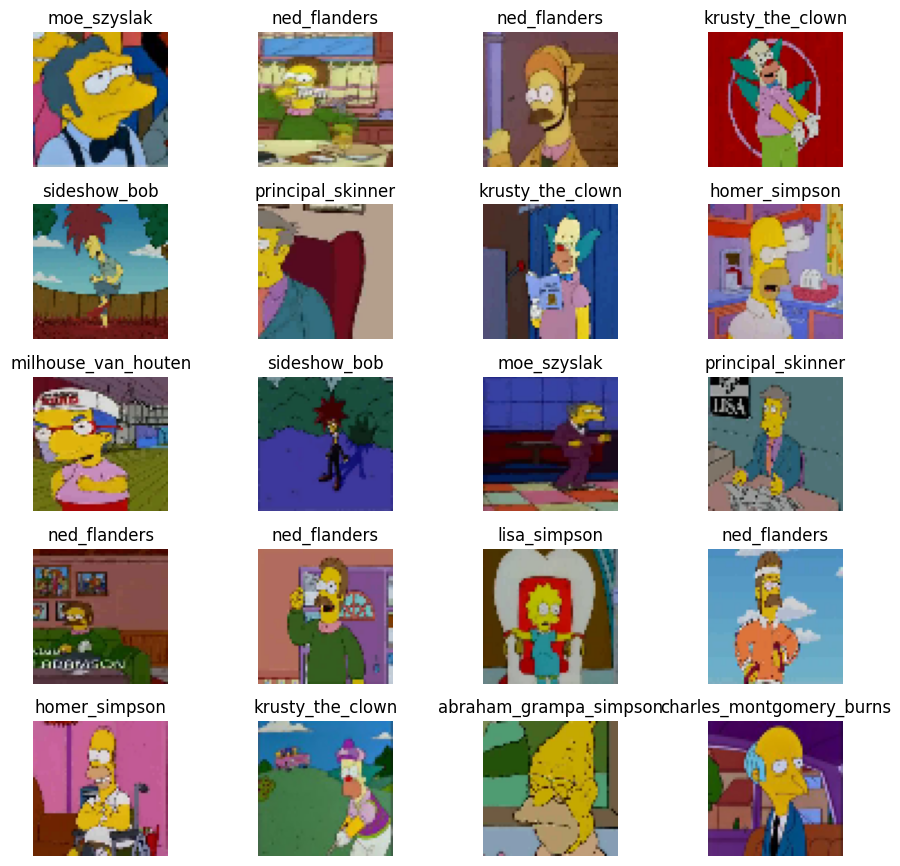

In [70]:
idx_sample = random.sample(range(0, 15185), 20)

display_images(X[idx_sample], y[idx_sample], 5, 4)

Elementos train set


Text(0, 0.5, 'Frecuencia')

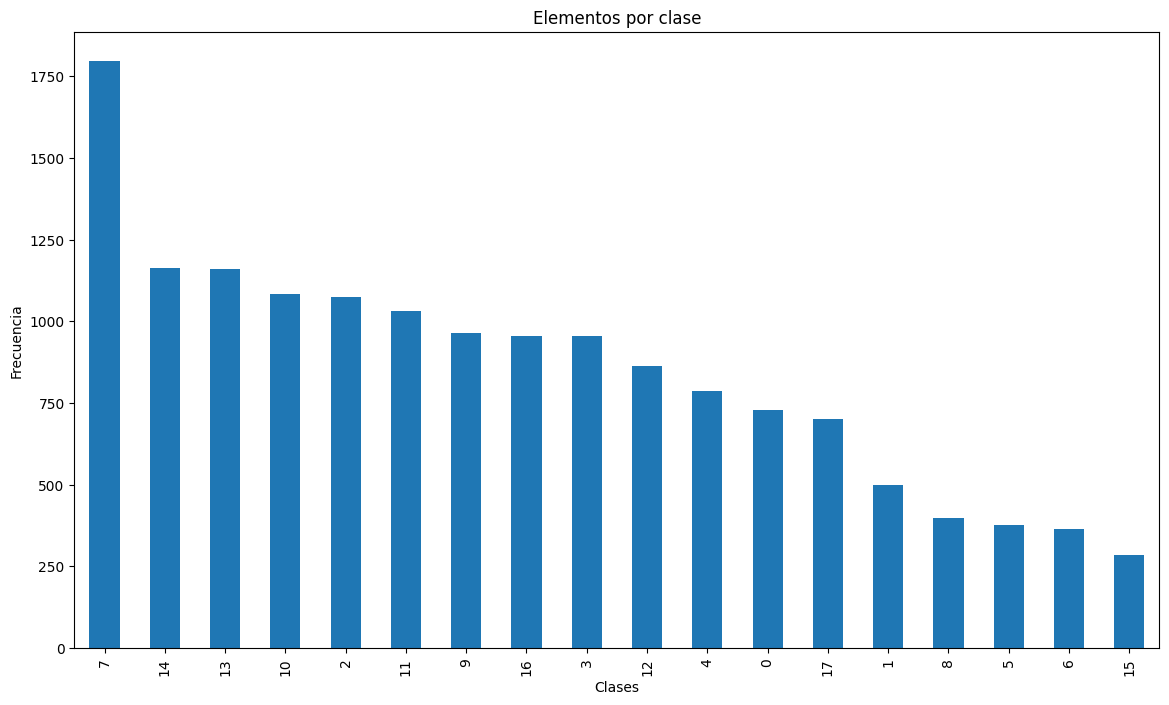

In [ ]:
print("Elementos train set")
ax = pd.Series(list(y)).value_counts().plot(kind='bar',
                                    figsize=(14,8),
                                    title="Elementos por clase")
ax.set_xlabel("Clases")
ax.set_ylabel("Frecuencia")

In [15]:
# imagenes para entrenamiento y validacion
X_train, X_valid, y_train, y_valid = train_test_split(X, y,
                                                    stratify=y,
                                                    test_size=0.2)

In [16]:
# normalizacion de las imagenes
X_train = X_train / 255.0
X_valid = X_valid / 255.0
X_test = X_t / 255.0

Elementos train set final


Text(0, 0.5, 'Frecuencia')

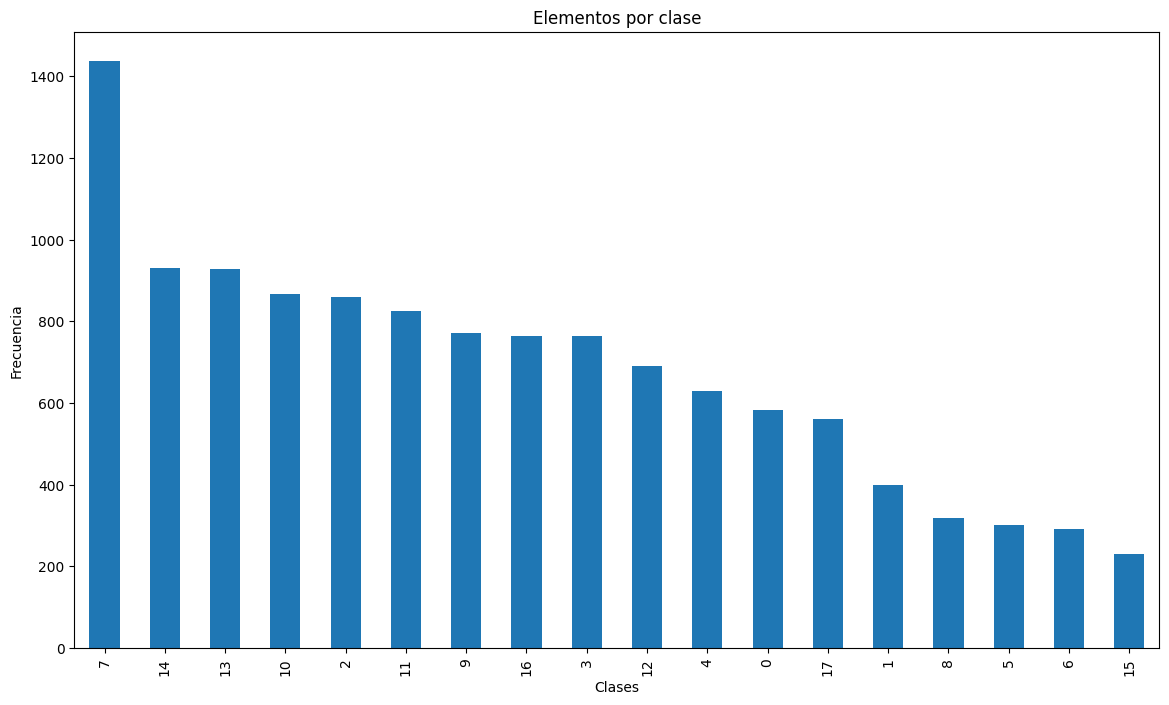

In [17]:
print("Elementos train set final")
ax = pd.Series(list(y_train)).value_counts().plot(kind='bar',
                                    figsize=(14,8),
                                    title="Elementos por clase")
ax.set_xlabel("Clases")
ax.set_ylabel("Frecuencia")

Elementos final validation set


Text(0, 0.5, 'Frecuencia')

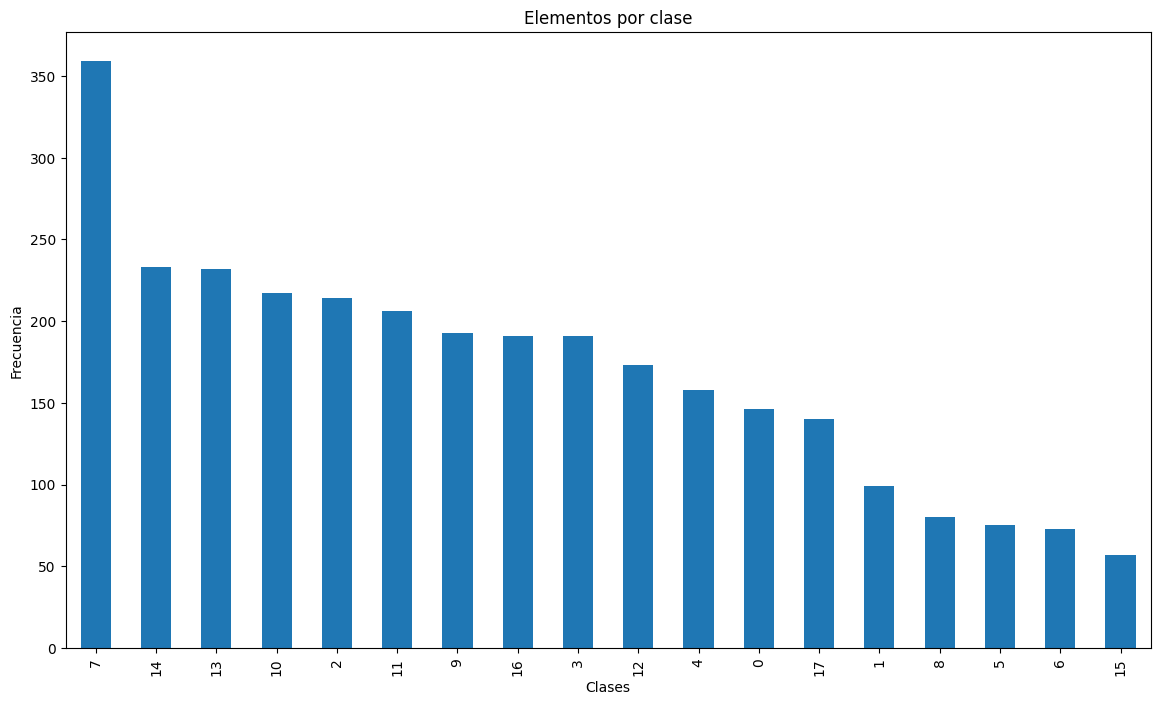

In [ ]:
print("Elementos final validation set")
ax = pd.Series(list(y_valid)).value_counts().plot(kind='bar',
                                    figsize=(14,8),
                                    title="Elementos por clase")
ax.set_xlabel("Clases")
ax.set_ylabel("Frecuencia")

In [18]:
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
    
)

# Generar las imágenes aumentadas en tiempo real
train_generator = datagen.flow(
    X_train, y_train,
    batch_size=32
)

In [20]:
# definimos el modelo propio, propuesto por Justin
modelo_propio_justin = Sequential()
# primera capa convolucional
modelo_propio_justin.add(Input(shape=(60, 60, 3)))
modelo_propio_justin.add(Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)))
modelo_propio_justin.add(BatchNormalization())
modelo_propio_justin.add(Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)))
modelo_propio_justin.add(BatchNormalization())
modelo_propio_justin.add(MaxPooling2D((2, 2)))
modelo_propio_justin.add(Dropout(0.10))

# segunda capa convolucional
modelo_propio_justin.add(Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)))
modelo_propio_justin.add(BatchNormalization())
modelo_propio_justin.add(Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)))
modelo_propio_justin.add(BatchNormalization())
modelo_propio_justin.add(MaxPooling2D((2, 2)))
modelo_propio_justin.add(Dropout(0.14))

# tercera capa convolucional
modelo_propio_justin.add(Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)))
modelo_propio_justin.add(BatchNormalization())
modelo_propio_justin.add(Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)))
modelo_propio_justin.add(BatchNormalization())
modelo_propio_justin.add(MaxPooling2D((2, 2)))
modelo_propio_justin.add(Dropout(0.16))

# capa fully conected y salida
modelo_propio_justin.add(Flatten())
modelo_propio_justin.add(Dense(512, activation='relu', kernel_regularizer=l2(0.001)))
modelo_propio_justin.add(Dropout(0.20))
modelo_propio_justin.add(Dense(18, activation='softmax'))

In [21]:
class_weights_sk = class_weight.compute_class_weight(
    class_weight = "balanced",
    classes = np.unique(y_train),
    y = y_train
)
class_weights_sk = dict(zip(set(y_train), class_weights_sk))
class_weights_sk

{0: 1.1556316590563165,
 1: 1.6914508493455862,
 2: 0.7856680895097659,
 3: 0.8845201689238387,
 4: 1.071252204585538,
 5: 2.2496296296296294,
 6: 2.311263318112633,
 7: 0.4696512796721565,
 8: 2.122292103424179,
 9: 0.8753422683383772,
 10: 0.7793174236592251,
 11: 0.8170567662093086,
 12: 0.9780998389694042,
 13: 0.72646812582227,
 14: 0.7256869772998805,
 15: 2.947113051916545,
 16: 0.8833624200116347,
 17: 1.2030104971281441}

In [22]:
modelo_propio_justin.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 60, 60, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 60, 60, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 60, 60, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 60, 60, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 15, 15, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 18)             │         9,23

 Total params: 3,509,810 (13.39 MB)

 Trainable params: 3,508,914 (13.39 MB)

 Non-trainable params: 896 (3.50 KB)

In [23]:
lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=10000,
    decay_rate=0.9)

In [35]:
# Exponential decay más suave para SGD
lr_schedule_sgd = ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=10000,
    decay_rate=0.95,  # antes 0.9, más suave
    staircase=True    # escalones en lugar de continuo, más estable
)

In [27]:
# Cosine Decay con reinicios: mejor que exponencial para CNNs profundas

# Warmup manual: empieza bajo y sube gradualmente
total_steps = (len(X_train) // 32) * 100  # pasos totales
warmup_steps = total_steps // 10           # 10% de warmup

steps_por_epoca = len(train_generator)  # pasos por época

cosine_schedule = CosineDecayRestarts(
    initial_learning_rate=5e-3,
    first_decay_steps=total_steps // 3,
    t_mul=2.0,       # cada reinicio dura el doble
    m_mul=0.9,       # el LR máximo baja un 10% en cada reinicio
    alpha=1e-6       # LR mínimo
)

In [84]:
# optimizadores
sgd_optimizer = SGD(
    learning_rate=lr_schedule_sgd,
    momentum=0.95,
    nesterov=True,
    use_ema=True,
    clipvalue=1.0
) # este es el que mejor ha funcionado
adam_optimizer = Adam(
    learning_rate=1e-3,#cosine_schedule,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7,     # default, más estable en Metal
    amsgrad=True,
    use_ema=True,
    clipvalue=1.0
)
rms_prop = RMSprop(
    learning_rate=1e-4,
    rho=0.90,
    momentum=0.90,
    epsilon=1e-7,
    use_ema=True,
    clipvalue=1.0
)



In [89]:
# callback para detener el entrenamiento al alcanzar el 90% de accuracy
class myCallback(tf.keras.callbacks.Callback):
      def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy')> 0.95):
              print("\nAlcanzado el 95% de precisión, se cancela el entrenamiento!!")
              self.model.stop_training = True

class BatchSizeScheduler(tf.keras.callbacks.Callback):
    def __init__(self, schedule, X_train, y_train, datagen):
        """
        schedule: dict {epoca_inicio: batch_size}
        Ejemplo: {0: 16, 5: 32, 15: 64}
        """
        super().__init__()
        self.schedule  = schedule
        self.X_train   = X_train
        self.y_train   = y_train
        self.datagen   = datagen

    def on_epoch_begin(self, epoch, logs=None):
        if epoch in self.schedule:
            nuevo_batch = self.schedule[epoch]
            # Reconstruye el generador con el nuevo batch size
            self.model._train_generator = self.datagen.flow(
                self.X_train,
                self.y_train,
                batch_size=nuevo_batch
            )
            print(f"\nBatch size actualizado → {nuevo_batch}")

# Instanciar
batch_scheduler = BatchSizeScheduler(
    schedule={0: 16, 10: 32, 25: 64},
    X_train=X_train,
    y_train=y_train,
    datagen=datagen
)

In [29]:
# ajustamos el learning_rate

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # antes 0.12 → reducción del 50%, mucho más suave
    patience=4,
    min_lr=1e-7,
    verbose=1
)

In [30]:
# Guarda el mejor modelo automáticamente
checkpoint = ModelCheckpoint(
    filepath='mejor_modelo_simpsons_hiperparametros.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [39]:
# configuramos el EarlyStop

early_stopping = EarlyStopping(
    monitor='val_loss',       # val_loss es más estable que val_accuracy
    patience=8,               # un poco más de margen
    restore_best_weights=True,
    verbose=1
)

In [87]:
#compilamos el modelo
# ── Compilación con precisión mixta (gran boost en M4) ───────────────
tf.keras.mixed_precision.set_global_policy('mixed_float16')

modelo_propio_justin.compile(
    optimizer=adam_optimizer,   # prueba adam primero con cosine schedule
    loss=SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)


In [90]:
modelo_propio_entrenado = modelo_propio_justin.fit(
                    train_generator,
                    epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[myCallback(), early_stopping, checkpoint, reduce_lr, batch_scheduler],
                    # batch_size = 32,
                    verbose = 1,
                    class_weight=class_weights_sk)


Batch size actualizado → 16
Epoch 1/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8181 - loss: 0.8807
Epoch 1: val_loss did not improve from 0.49281
380/380 ━━━━━━━━━━━━━━━━━━━━ 28s 65ms/step - accuracy: 0.8267 - loss: 0.8544 - val_accuracy: 0.9065 - val_loss: 0.6368 - learning_rate: 2.5000e-04
Epoch 2/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8422 - loss: 0.7841
Epoch 2: val_loss did not improve from 0.49281
380/380 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.8453 - loss: 0.7733 - val_accuracy: 0.9055 - val_loss: 0.6205 - learning_rate: 2.5000e-04
Epoch 3/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8389 - loss: 0.7589
Epoch 3: val_loss did not improve from 0.49281
380/380 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - accuracy: 0.8427 - loss: 0.7536 - val_accuracy: 0.9075 - val_loss: 0.6094 - learning_rate: 2.5000e-04
Epoch 4/100
380/380 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8486 - loss: 0.7465
Epoch 4: val_loss did not improve fro

In [ ]:
# guardamos el modelo
# modelo_propio_justin.save('/content/drive/MyDrive/modelo_propio_justin.h5')
# tambien lo podemos guardar como modelo_propio_justin.save('/content/drive/MyDrive/modelo_propio_justin.keras')

***Este ultimo modelo guardado llego a un accuracy del 93%***
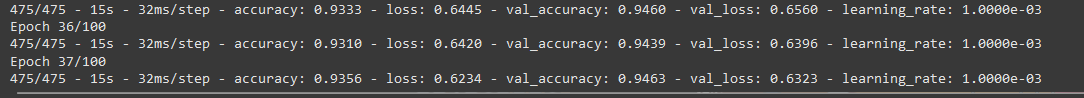

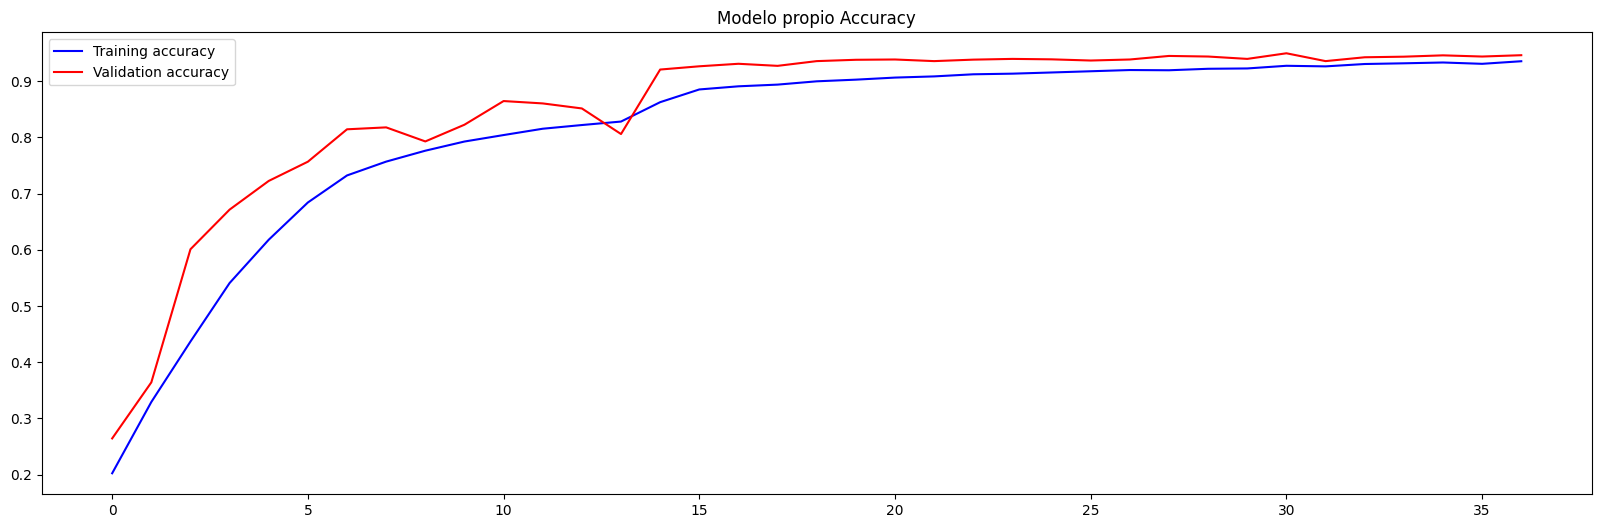

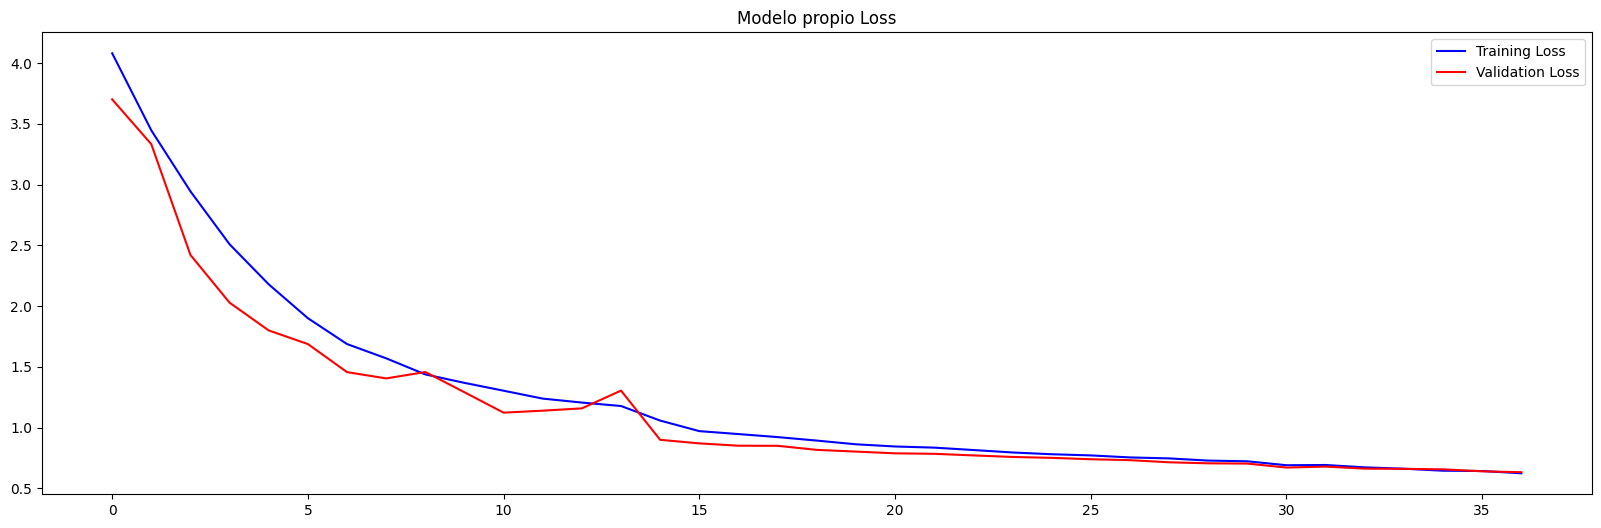

In [ ]:
PlotPerformance(modelo_propio_entrenado.history['accuracy'],
                modelo_propio_entrenado.history['val_accuracy'],
                modelo_propio_entrenado.history['loss'],
                modelo_propio_entrenado.history['val_loss'],
                'Modelo propio')

Agregamos las imagenes de las graficas para no perderlas

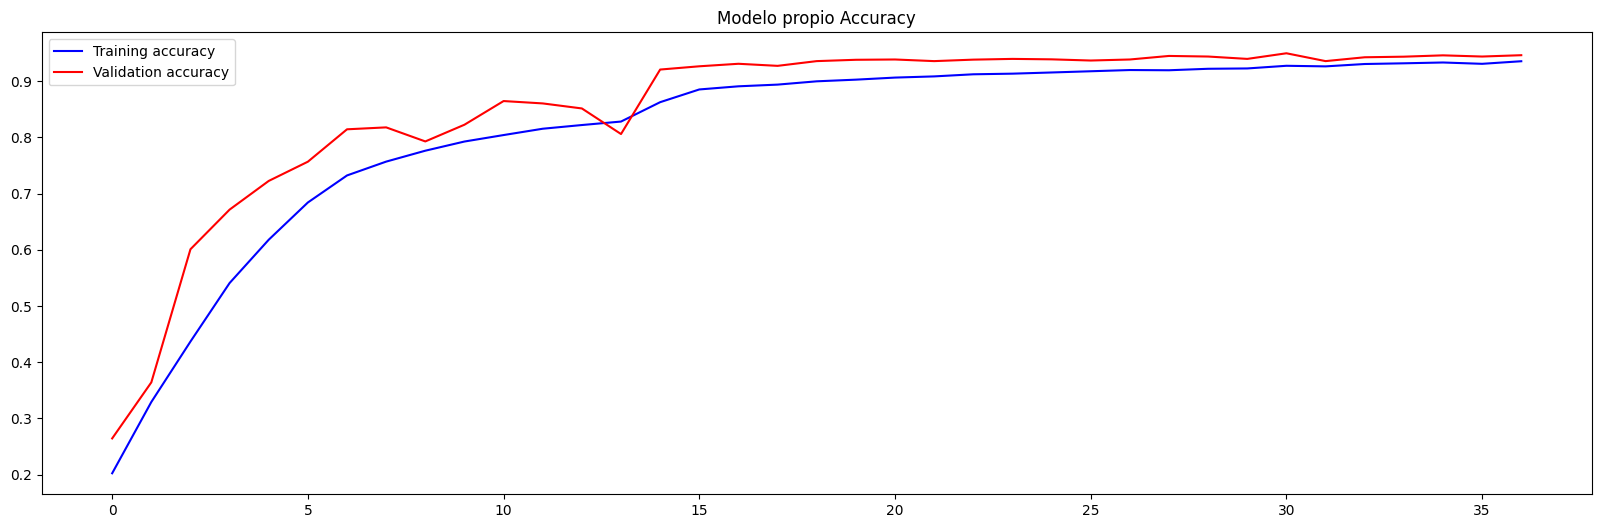

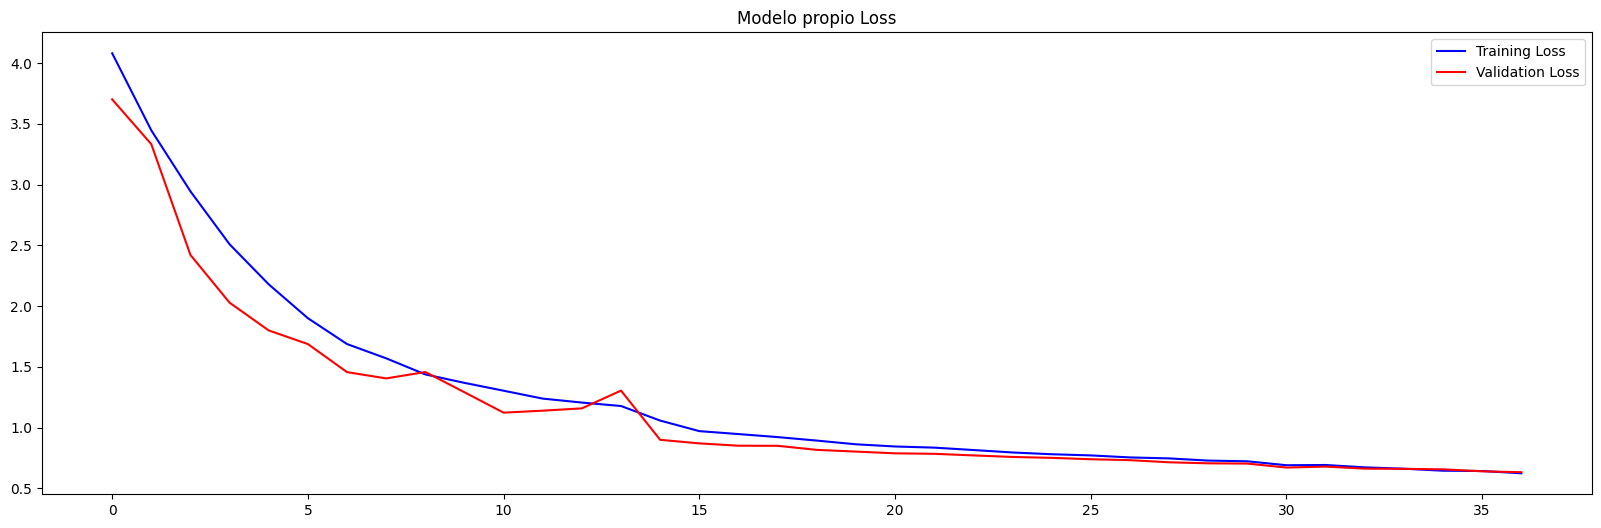

In [ ]:
# cargamos el modelo guardado
modelo_propio_guardado = load_model('/content/drive/MyDrive/modelo_propio_justin.h5')

In [ ]:
# hacemos una prediccion con el conjunto de test para evaluar resultados
y_pred = modelo_propio_guardado.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
print(classification_report(y_t, y_pred, target_names=list_caracters))

28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step
                          precision    recall  f1-score   support

  abraham_grampa_simpson       1.00      0.90      0.95        48
  apu_nahasapeemapetilon       0.96      1.00      0.98        50
            bart_simpson       0.98      0.96      0.97        50
charles_montgomery_burns       0.98      0.90      0.93        48
            chief_wiggum       1.00      1.00      1.00        50
          comic_book_guy       0.98      0.96      0.97        49
          edna_krabappel       0.98      0.98      0.98        50
           homer_simpson       0.84      0.98      0.91        50
           kent_brockman       1.00      1.00      1.00        50
        krusty_the_clown       1.00      1.00      1.00        50
            lisa_simpson       0.98      0.96      0.97        50
           marge_simpson       0.96      1.00      0.98        50
     milhouse_van_houten       0.94      0.98      0.96        49
             moe_szyslak       1.00

***Agregamos las imagenes de evidencia del modelo guardado***

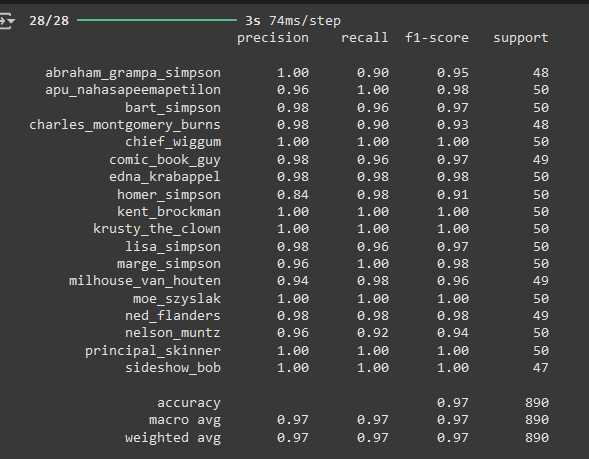

In [ ]:
# creamos un modelo con transfer learning basandonos en el modelo EfficientNetB4
pre_trained_model = EfficientNetB4(weights='imagenet',
                                  include_top=False,
                                  input_shape=(60, 60, 3))

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
# hacemos que las capas de pre_trained_model
for layer in pre_trained_model.layers:
  layer.trainable = False

In [ ]:
# resumen de la arquitectura pre entrenada
pre_trained_model.summary()

Model: "efficientnetb4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 60, 60, 3)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 60, 60, 3)      │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 60, 60, 3)      │              7 │ rescaling[0][0]        │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_1 (Rescaling)   │ (None, 60, 60, 3)      │              0 │ normalization[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 61, 61, 3)      │              0 │ rescaling_1[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 30, 30, 48)     │          1,296 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 30, 30, 48)     │            192 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 30, 30, 48)     │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 30, 30, 48)     │            432 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 30, 30, 48)     │            192 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 30, 30, 48)     │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 48)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 48)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 12)       │            588 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_expand    

 Total params: 17,673,823 (67.42 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 17,673,823 (67.42 MB)

In [ ]:
# agregamos una ultima capa fully conected al modelo pre entrenado

rms_optimizer = RMSprop(learning_rate=0.01, rho=0.9)
sgd_optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
adam_optimizer = Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.999)
adagrad_optimizer = Adagrad(learning_rate=0.01)
# aplanamos la salida del modelo
x = layers.GlobalAveragePooling2D()(pre_trained_model.output)
x = layers.Flatten()(x)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.10)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.12)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
# x = layers.Dense(64, activation='relu')(X)
# Add a final sigmoid layer for classification
x = layers.Dense(18, activation='sigmoid')(x)

model = Model(pre_trained_model.input, x)

model.compile(optimizer=rms_optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# entrenamos nuestro nuevo modelo
modelo_preentrenado_1 = model.fit(train_generator,
                    epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[myCallback(), early_stopping, reduce_lr],
                    batch_size = 32,
                    verbose = 2,
                    class_weight=class_weights_sk)

Epoch 1/100
475/475 - 91s - 191ms/step - accuracy: 0.0558 - loss: 4.6503 - val_accuracy: 0.0569 - val_loss: 2.8883 - learning_rate: 0.0100
Epoch 2/100
475/475 - 17s - 35ms/step - accuracy: 0.0502 - loss: 2.8933 - val_accuracy: 0.0263 - val_loss: 2.8886 - learning_rate: 0.0100
Epoch 3/100
475/475 - 17s - 36ms/step - accuracy: 0.0462 - loss: 2.8933 - val_accuracy: 0.0190 - val_loss: 2.8925 - learning_rate: 0.0100
Epoch 4/100
475/475 - 17s - 35ms/step - accuracy: 0.0498 - loss: 2.8928 - val_accuracy: 0.0329 - val_loss: 2.8975 - learning_rate: 0.0100
Epoch 5/100
475/475 - 17s - 35ms/step - accuracy: 0.0346 - loss: 2.8917 - val_accuracy: 0.0482 - val_loss: 2.8925 - learning_rate: 1.0000e-03
Epoch 6/100
475/475 - 17s - 36ms/step - accuracy: 0.0481 - loss: 2.8910 - val_accuracy: 0.0482 - val_loss: 2.8910 - learning_rate: 1.0000e-03


In [ ]:
# MobileNetV2, NASNetMobile, Xception, ResNet50V2
pre_trained_model_2 = MobileNetV2(
    input_shape = (60, 60, 3),
    include_top = False,
    weights = 'imagenet')

<ipython-input-39-4fa0572b711a>:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  pre_trained_model_2 = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# hacemos modelo con fine tuning
for layer in pre_trained_model_2.layers:
  layer.trainable = True

# resumen de la arquitectura pre entrenada
pre_trained_model_2.summary()

# optimizadores
rms_optimizer = RMSprop(learning_rate=0.01, rho=0.9)
sgd_optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
adam_optimizer = Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.999)
adagrad_optimizer = Adagrad(learning_rate=0.01)


# aplanamos la salida del modelo
x = layers.GlobalAveragePooling2D()(pre_trained_model_2.output)
x = layers.Flatten()(x)
# Add a fully connected layer with 1,024 hidden units and ReLU activation
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.10)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.12)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
# Add a final sigmoid layer for classification
x = layers.Dense(18, activation='sigmoid')(x)

model = Model(pre_trained_model_2.input, x)

model.compile(optimizer=adagrad_optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

modelo_preentrenado_2 = model.fit(train_generator,
                    epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[myCallback(), early_stopping, reduce_lr],
                    batch_size = 32,
                    verbose = 2,
                    class_weight=class_weights_sk)

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 60, 60, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 30, 30, 32)     │            864 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 30, 30, 32)     │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 30, 30, 32)     │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 30, 30, 32)     │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 30, 30, 32)     │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 30, 30, 32)     │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 30, 30, 16)     │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 30, 30, 16)     │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 30, 30, 96)     │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 30, 30, 96)     │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 30, 30, 96)     │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 31, 31, 96)     │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 15, 15, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

Epoch 1/100
475/475 - 87s - 184ms/step - accuracy: 0.1296 - loss: 2.7366 - val_accuracy: 0.1163 - val_loss: 8.8688 - learning_rate: 0.0100
Epoch 2/100
475/475 - 16s - 34ms/step - accuracy: 0.3934 - loss: 1.8927 - val_accuracy: 0.1585 - val_loss: 4.8763 - learning_rate: 0.0100
Epoch 3/100
475/475 - 16s - 34ms/step - accuracy: 0.5807 - loss: 1.3160 - val_accuracy: 0.2727 - val_loss: 4.3275 - learning_rate: 0.0100
Epoch 4/100
475/475 - 16s - 33ms/step - accuracy: 0.6776 - loss: 1.0221 - val_accuracy: 0.3809 - val_loss: 3.3406 - learning_rate: 0.0100
Epoch 5/100
475/475 - 16s - 33ms/step - accuracy: 0.7295 - loss: 0.8687 - val_accuracy: 0.6533 - val_loss: 1.5321 - learning_rate: 0.0100
Epoch 6/100
475/475 - 16s - 33ms/step - accuracy: 0.7574 - loss: 0.7607 - val_accuracy: 0.6533 - val_loss: 1.5135 - learning_rate: 0.0100
Epoch 7/100
475/475 - 16s - 33ms/step - accuracy: 0.7783 - loss: 0.6998 - val_accuracy: 0.7678 - val_loss: 0.8511 - learning_rate: 0.0100
Epoch 8/100
475/475 - 16s - 34ms/

In [ ]:
# salvamos el modelo hecho con fine tuning
# este es mas un ajuste fino que un transfer learning
# model.save('/content/drive/MyDrive/modelo_preentrenado_2.keras')

***nuestro primer modelo con fine tunning alcanzo un accuracy del 93%, similar al modelo hecho desde 0***

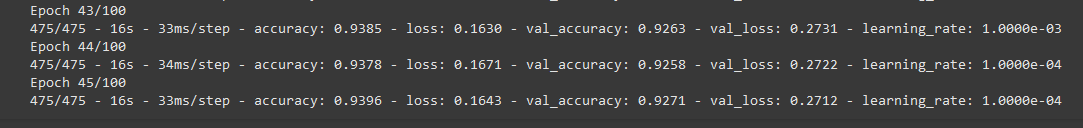

In [ ]:
# cargamos el modelo guardado en drive
modelo_preentrenado_guardado_2 = load_model('/content/drive/MyDrive/modelo_preentrenado_2.keras')

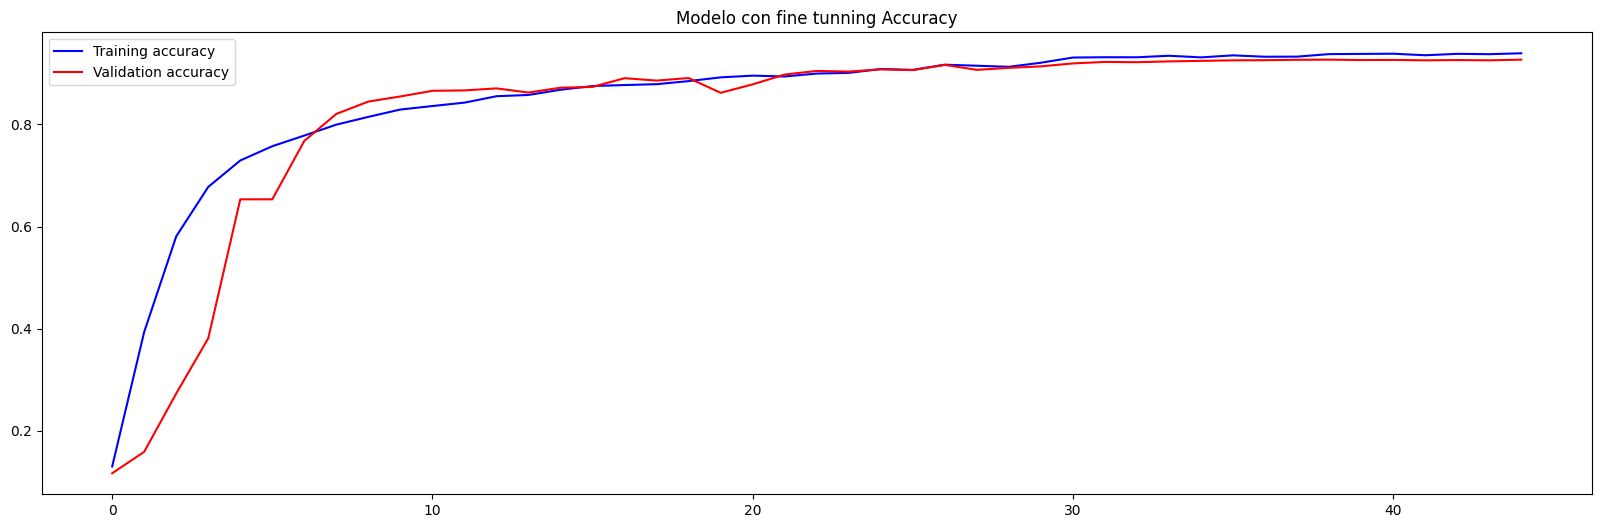

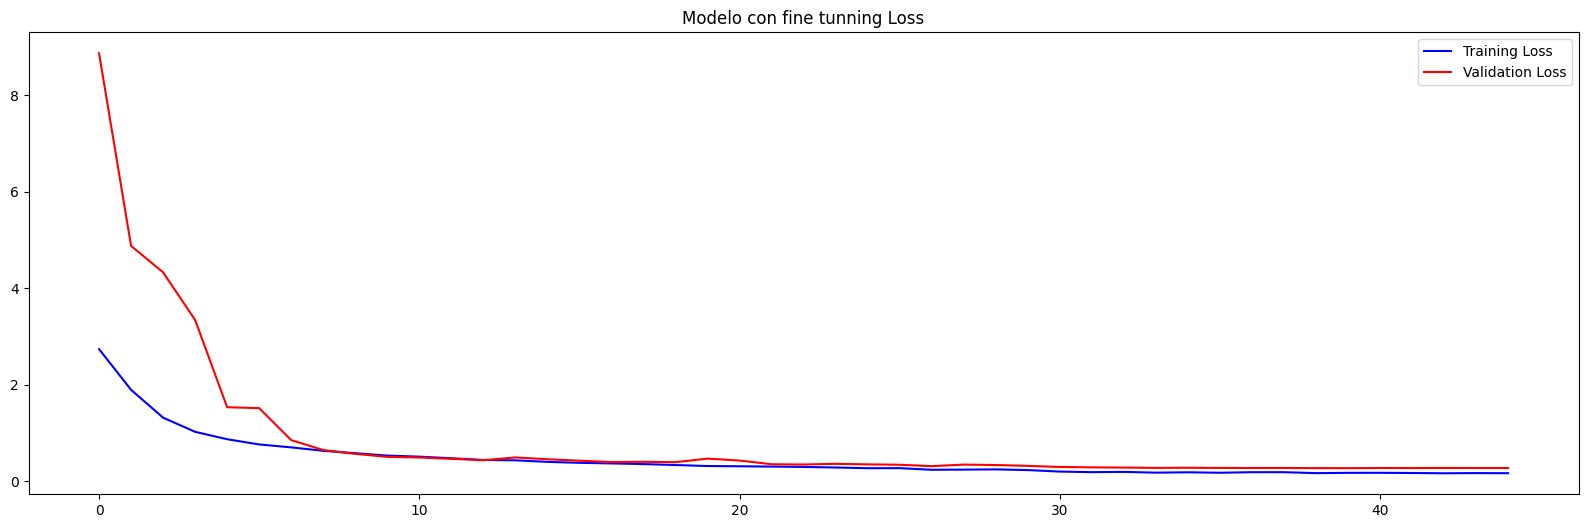

In [ ]:
PlotPerformance(modelo_preentrenado_2.history['accuracy'],
                modelo_preentrenado_2.history['val_accuracy'],
                modelo_preentrenado_2.history['loss'],
                modelo_preentrenado_2.history['val_loss'],
                'Modelo con fine tunning')

***Graficas de primer modelo con ajuste fino***

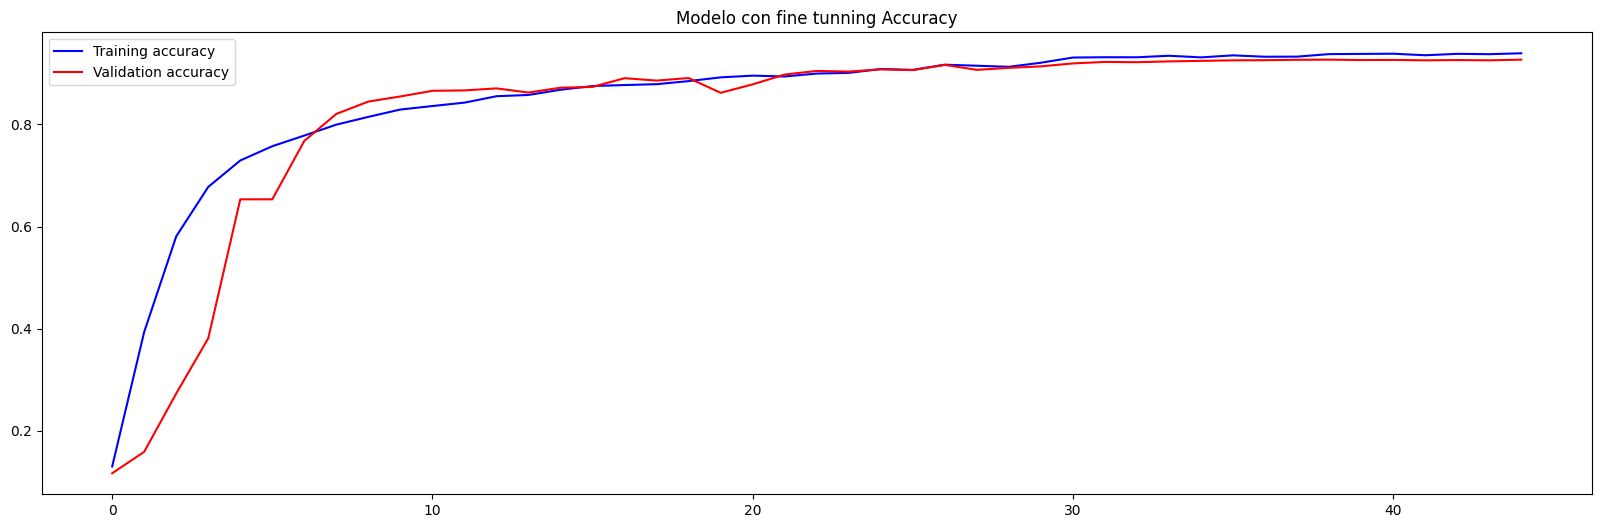

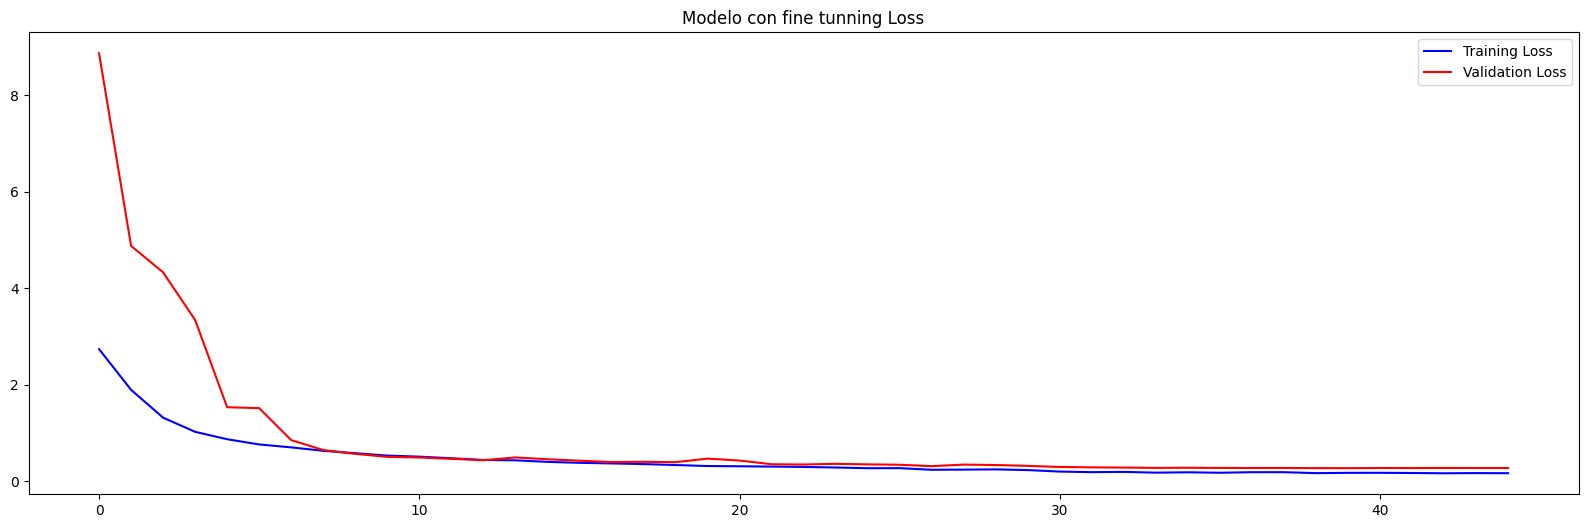

In [ ]:
# hacemos una prediccion con el conjunto de test para evaluar resultados
y_pred = modelo_preentrenado_guardado_2.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
print(classification_report(y_t, y_pred, target_names=list_caracters))

28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 386ms/step
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.98      0.92      0.95        48
  apu_nahasapeemapetilon       1.00      1.00      1.00        50
            bart_simpson       0.92      0.96      0.94        50
charles_montgomery_burns       0.90      0.96      0.93        48
            chief_wiggum       0.93      1.00      0.96        50
          comic_book_guy       0.96      0.98      0.97        49
          edna_krabappel       0.98      0.94      0.96        50
           homer_simpson       0.96      0.92      0.94        50
           kent_brockman       1.00      0.98      0.99        50
        krusty_the_clown       1.00      1.00      1.00        50
            lisa_simpson       0.98      0.88      0.93        50
           marge_simpson       0.98      1.00      0.99        50
     milhouse_van_houten       1.00      1.00      1.00        49
             moe_szyslak       0.

***Resultados del modelo con fine tuning con accuracy del 93%***

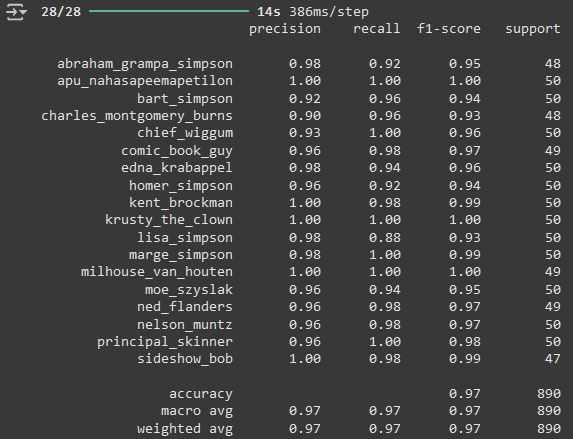

In [ ]:
pre_trained_model_3 = NASNetMobile(
    input_shape = (60, 60, 3),
    include_top = False,
    weights = 'imagenet')


In [ ]:
# segundo modelo con fine tuning
for layer in pre_trained_model_3.layers[300:]:
  layer.trainable = True

# resumen de la arquitectura pre entrenada
pre_trained_model_3.summary()

# # optimizadores
rms_optimizer = RMSprop(learning_rate=0.01, rho=0.9)
sgd_optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
adam_optimizer = Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.999)
adagrad_optimizer = Adagrad(learning_rate=0.01)


# aplanamos la salida del modelo
x = layers.GlobalAveragePooling2D()(pre_trained_model_3.output)
x = layers.Flatten()(x)
# Add a fully connected layer with 1,024 hidden units and ReLU activation
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.10)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.12)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
# Add a final sigmoid layer for classification
x = layers.Dense(18, activation='sigmoid')(x)

model = Model(pre_trained_model_3.input, x)

model.compile(optimizer=sgd_optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

modelo_preentrenado_3 = model.fit(train_generator,
                    epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[myCallback(), early_stopping, reduce_lr],
                    batch_size = 32,
                    verbose = 2,
                    class_weight=class_weights_sk)


Model: "nasnet_mobile"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 60, 60, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv1 (Conv2D)       │ (None, 29, 29, 32)     │            864 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn1                  │ (None, 29, 29, 32)     │            128 │ stem_conv1[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_376            │ (None, 29, 29, 32)     │              0 │ stem_bn1[0][0]         │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reduction_conv_1_stem_1   │ (None, 29, 29, 11)     │            352 │ activation_376[0][0]   │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reduction_bn_1_stem_1     │ (None, 29, 29, 11)     │             44 │ reduction_conv_1_stem… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_377            │ (None, 29, 29, 11)     │              0 │ reduction_bn_1_stem_1… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_379            │ (None, 29, 29, 32)     │              0 │ stem_bn1[0][0]         │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv_1_pad_red… │ (None, 33, 33, 11)     │              0 │ activation_377[0][0]   │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv_1_pad_red… │ (None, 35, 35, 32)     │              0 │ activation_379[0][0]   │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv_1_reducti… │ (None, 15, 15, 11)     │            396 │ separable_conv_1_pad_… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv_1_reducti… │ (None, 15, 15, 11)     │          1,920 │ separable_conv_1_pad_… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv_1_bn_redu… │ (None, 15, 15, 11)     │             44 │ separable_conv_1_redu… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv_1_bn_r

 Total params: 4,269,716 (16.29 MB)

 Trainable params: 4,232,978 (16.15 MB)

 Non-trainable params: 36,738 (143.51 KB)

Epoch 1/100
475/475 - 229s - 481ms/step - accuracy: 0.0531 - loss: 2.8780 - val_accuracy: 0.0705 - val_loss: 410784.1875 - learning_rate: 0.0100
Epoch 2/100
475/475 - 24s - 50ms/step - accuracy: 0.0473 - loss: 2.8610 - val_accuracy: 0.0329 - val_loss: 56537.6016 - learning_rate: 0.0100
Epoch 3/100
475/475 - 24s - 50ms/step - accuracy: 0.0694 - loss: 2.8391 - val_accuracy: 0.0640 - val_loss: 2457.4441 - learning_rate: 0.0100
Epoch 4/100
475/475 - 24s - 51ms/step - accuracy: 0.0615 - loss: 2.8162 - val_accuracy: 0.0742 - val_loss: 921.8407 - learning_rate: 0.0100
Epoch 5/100
475/475 - 24s - 50ms/step - accuracy: 0.0769 - loss: 2.7680 - val_accuracy: 0.0690 - val_loss: 353.9614 - learning_rate: 0.0100
Epoch 6/100


KeyboardInterrupt: 